In [16]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import DBSCAN

from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import dendrogram, linkage

In [17]:
file= 'EastWestAirlines.xlsx'

df = pd.read_excel(file, 
                        sheet_name = 1, 
                        index_col = 0)
#or we can also read file using df = pd.read_excel("EastWestAirlines.xlsx", sheet_name="data")

In [18]:
df.head()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
ID#,,,,,,,,,,,
1,28143,0,1,1,1,174,1,0,0,7000,0
2,19244,0,1,1,1,215,2,0,0,6968,0
3,41354,0,1,1,1,4123,4,0,0,7034,0
4,14776,0,1,1,1,500,1,0,0,6952,0
5,97752,0,4,1,1,43300,26,2077,4,6935,1


In [19]:
df.shape

(3999, 11)

In [20]:
#View Columns
df.columns

Index(['Balance', 'Qual_miles', 'cc1_miles', 'cc2_miles', 'cc3_miles',
       'Bonus_miles', 'Bonus_trans', 'Flight_miles_12mo', 'Flight_trans_12',
       'Days_since_enroll', 'Award?'],
      dtype='object')

In [21]:
#dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3999 entries, 1 to 4021
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Balance            3999 non-null   int64
 1   Qual_miles         3999 non-null   int64
 2   cc1_miles          3999 non-null   int64
 3   cc2_miles          3999 non-null   int64
 4   cc3_miles          3999 non-null   int64
 5   Bonus_miles        3999 non-null   int64
 6   Bonus_trans        3999 non-null   int64
 7   Flight_miles_12mo  3999 non-null   int64
 8   Flight_trans_12    3999 non-null   int64
 9   Days_since_enroll  3999 non-null   int64
 10  Award?             3999 non-null   int64
dtypes: int64(11)
memory usage: 374.9 KB


In [22]:
#Statistical Summary
df.describe()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
count,3.999000e+03,3999.000000,3999.000000,3999.000000,3999.000000,3999.000000,3999.00000,3999.000000,3999.000000,3999.00000,3999.000000
mean,7.360133e+04,144.114529,2.059515,1.014504,1.012253,17144.846212,11.60190,460.055764,1.373593,4118.55939,0.370343
std,1.007757e+05,773.663804,1.376919,0.147650,0.195241,24150.967826,9.60381,1400.209171,3.793172,2065.13454,0.482957
min,0.000000e+00,0.000000,1.000000,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,2.00000,0.000000
25%,1.852750e+04,0.000000,1.000000,1.000000,1.000000,1250.000000,3.00000,0.000000,0.000000,2330.00000,0.000000
50%,4.309700e+04,0.000000,1.000000,1.000000,1.000000,7171.000000,12.00000,0.000000,0.000000,4096.00000,0.000000
75%,9.240400e+04,0.000000,3.000000,1.000000,1.000000,23800.500000,17.00000,311.000000,1.000000,5790.50000,1.000000
max,1.704838e+06,11148.000000,5.000000,3.000000,5.000000,263685.000000,86.00000,30817.000000,53.000000,8296.00000,1.000000


In [23]:
#Check Missing Values
df.isnull().sum()

Balance              0
Qual_miles           0
cc1_miles            0
cc2_miles            0
cc3_miles            0
Bonus_miles          0
Bonus_trans          0
Flight_miles_12mo    0
Flight_trans_12      0
Days_since_enroll    0
Award?               0
dtype: int64

In [24]:
#Check Duplicate Rows
df.duplicated().sum()

1

In [25]:
#duplicates exist

df = df.drop_duplicates()

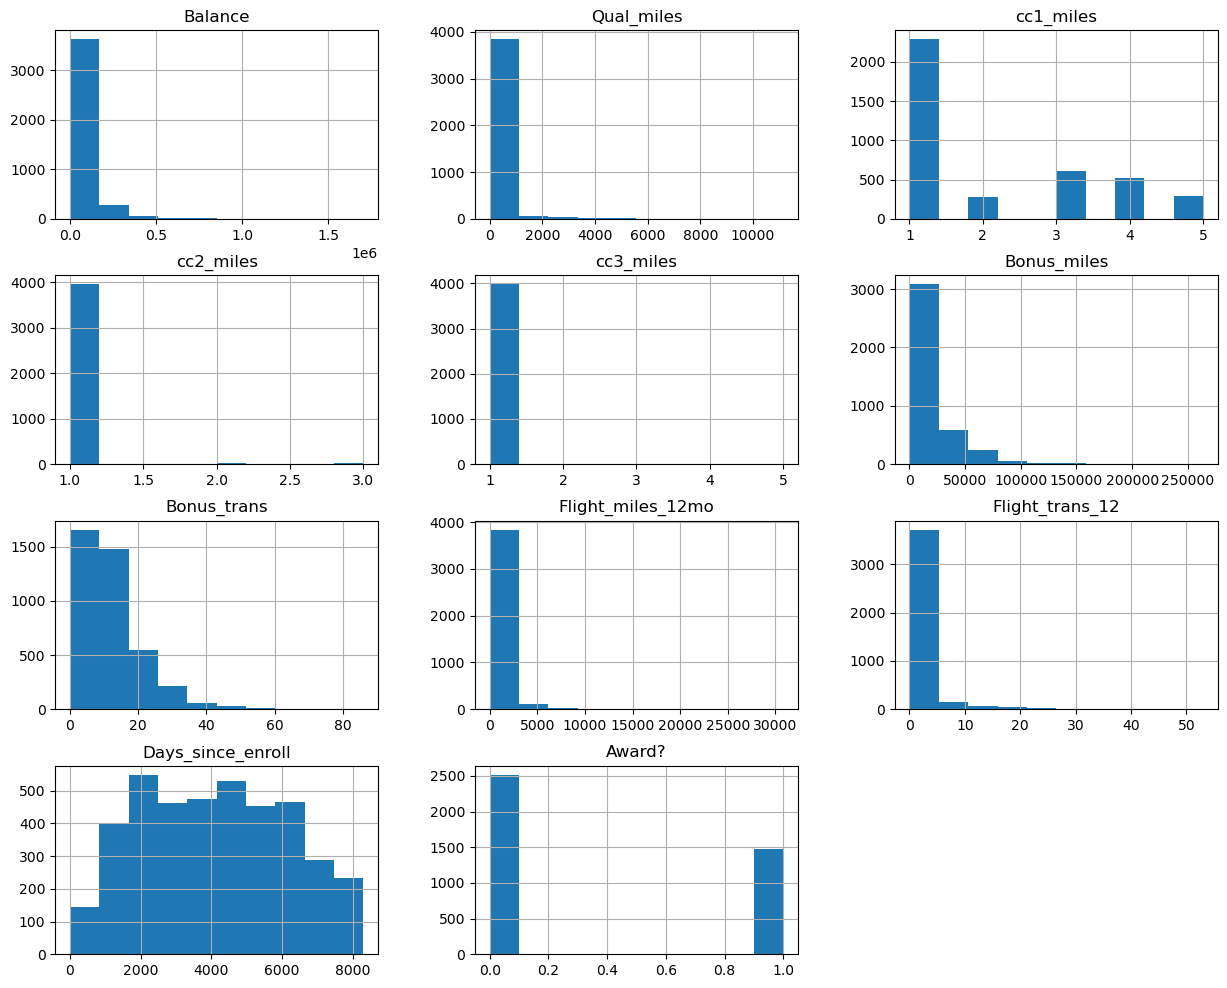

In [26]:
#Exploratory Data Analysis
#Histogram
df.hist(figsize=(15,12))
plt.show()

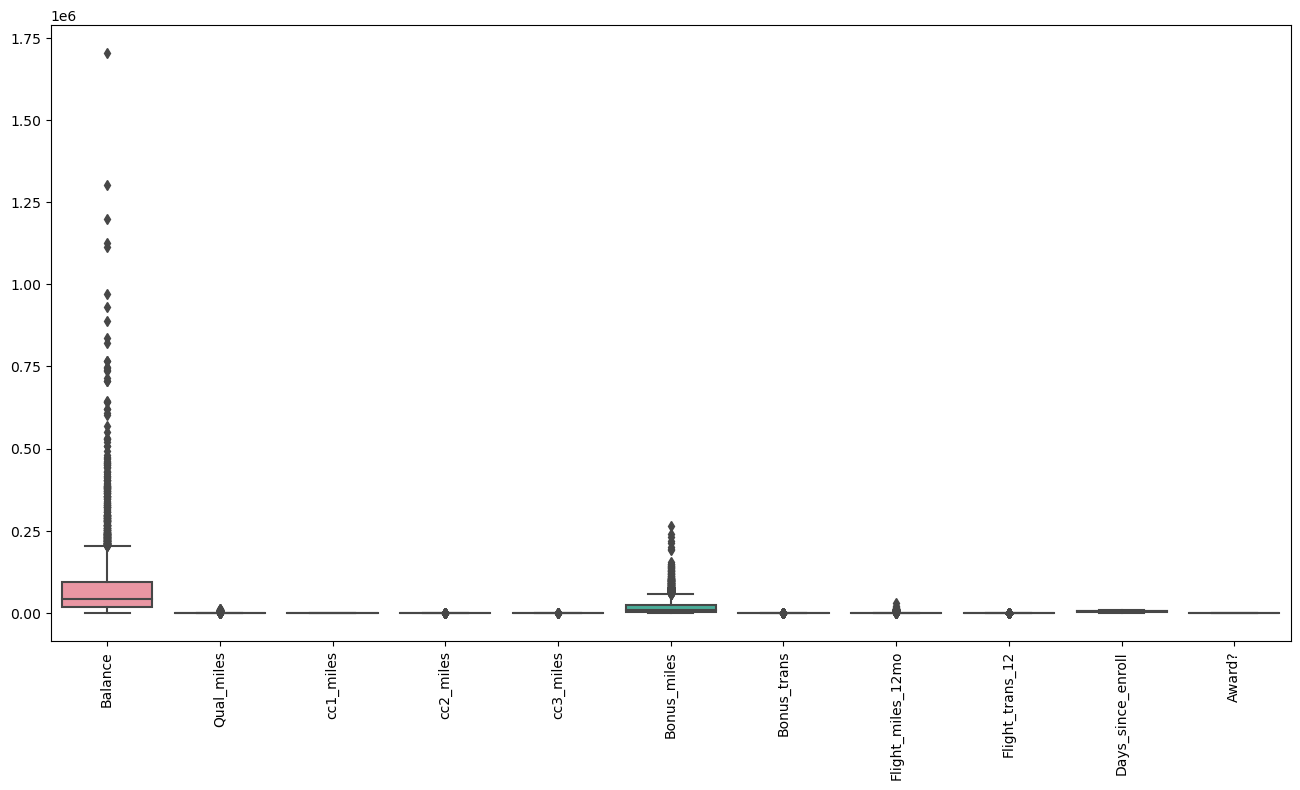

In [27]:
#Boxplot
plt.figure(figsize=(16,8))
sns.boxplot(data=df)

plt.xticks(rotation=90)

plt.show()

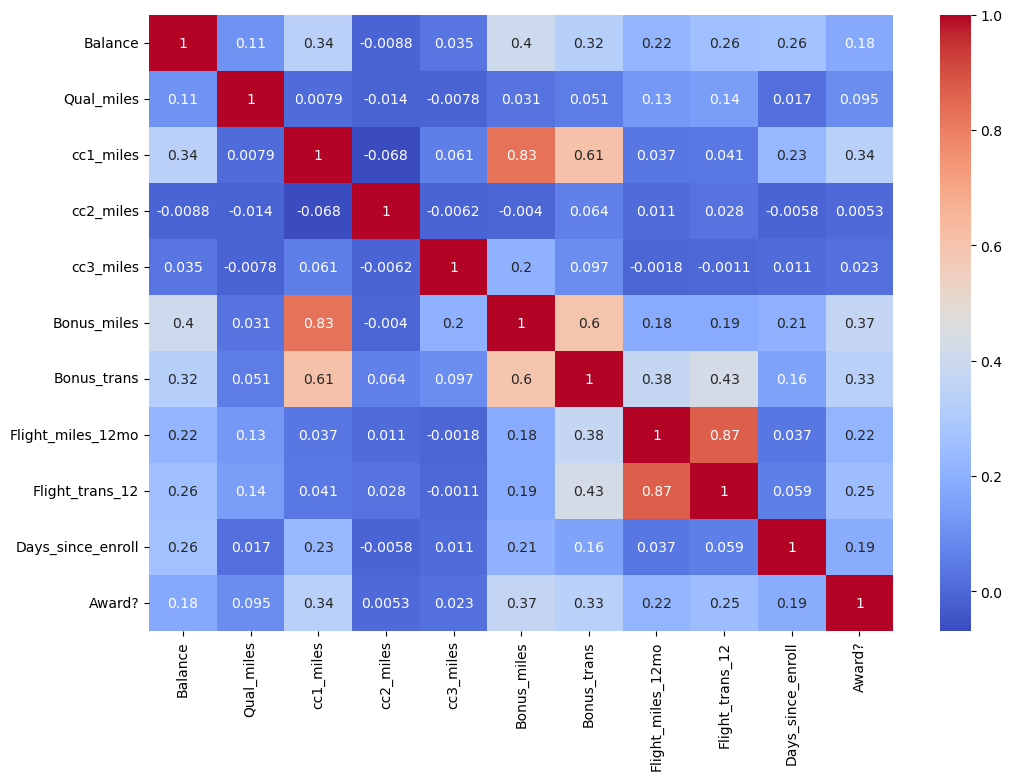

In [29]:
#Correlation Heatmap
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(),
            annot=True,
            cmap="coolwarm")

plt.show()

In [31]:
#Remove Customer ID

#IDs do not help clustering.

#First check columns

df.columns

Index(['Balance', 'Qual_miles', 'cc1_miles', 'cc2_miles', 'cc3_miles',
       'Bonus_miles', 'Bonus_trans', 'Flight_miles_12mo', 'Flight_trans_12',
       'Days_since_enroll', 'Award?'],
      dtype='object')

In [32]:
#if dataset contains

#ID#

#remove it

df = df.drop("ID#", axis=1)

KeyError: "['ID#'] not found in axis"

In [59]:
#Feature Scaling

#Very important.

scaler = StandardScaler()

scaled = scaler.fit_transform(df)
print(scaled)

[[-4.51293870e-01 -1.86322793e-01 -7.69731660e-01 ...  4.91254076e-01
   5.02315236e-01 -3.03373453e-01]
 [-5.39604653e-01 -1.86322793e-01 -7.69731660e-01 ...  4.91254076e-01
   5.02315236e-01 -3.03373453e-01]
 [-3.20192202e-01 -1.86322793e-01 -7.69731660e-01 ...  4.91254076e-01
   5.02315236e-01 -3.03373453e-01]
 ...
 [-2.23153612e-04 -1.86322793e-01  6.82893866e-01 ... -1.32225820e+00
  -1.22299088e+00  1.25360609e+00]
 [-1.85776026e-01 -1.86322793e-01 -7.69731660e-01 ...  4.91254076e-01
   5.02315236e-01 -3.03373453e-01]
 [-7.00646048e-01 -1.86322793e-01 -7.69731660e-01 ...  4.91254076e-01
   5.02315236e-01 -3.03373453e-01]]


In [34]:
#Convert back to DataFrame

scaled_df = pd.DataFrame(scaled,
                         columns=df.columns)

scaled_df.head()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,-0.451294,-0.186323,-0.769732,-0.098254,-0.062774,-0.702920,-1.104430,-0.328649,-0.362219,1.395235,-0.767072
1,-0.539605,-0.186323,-0.769732,-0.098254,-0.062774,-0.701223,-1.000286,-0.328649,-0.362219,1.379736,-0.767072
2,-0.320192,-0.186323,-0.769732,-0.098254,-0.062774,-0.539397,-0.791997,-0.328649,-0.362219,1.411702,-0.767072
3,-0.583944,-0.186323,-0.769732,-0.098254,-0.062774,-0.689421,-1.104430,-0.328649,-0.362219,1.371987,-0.767072
4,0.239483,-0.186323,1.409207,-0.098254,-0.062774,1.082876,1.499179,1.154721,0.692324,1.363754,1.303659


In [35]:
#kMEANS CLUSTERING
#Step 14: Elbow Method
wcss = []

for i in range(1,11):

    model = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    model.fit(scaled_df)

    wcss.append(model.inertia_)

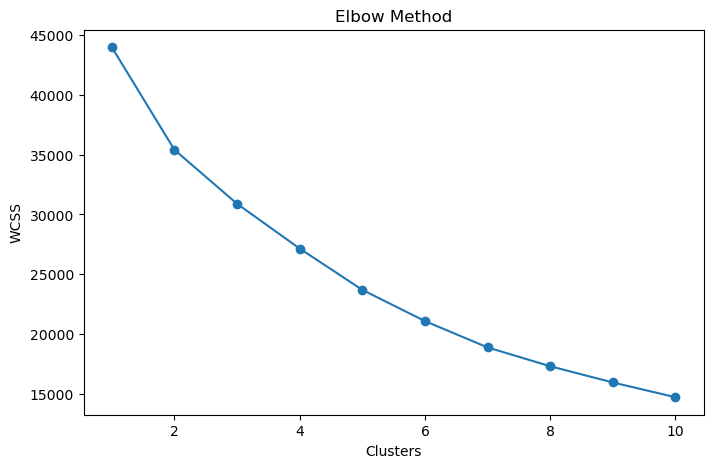

In [36]:
#Step 15: Plot Elbow
plt.figure(figsize=(8,5))

plt.plot(range(1,11),
         wcss,
         marker='o')

plt.xlabel("Clusters")

plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.show()

In [37]:
#Train KMeans
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

kmeans.fit(scaled_df)

KMeans(n_clusters=4, n_init=10, random_state=42)

In [38]:
#Cluster Labels
labels = kmeans.labels_

labels

array([1, 1, 1, ..., 0, 1, 1])

In [39]:
#Add Labels
df["KMeans_Cluster"] = labels

In [40]:
#Cluster Count
df["KMeans_Cluster"].value_counts()

KMeans_Cluster
1    2534
0    1281
2     168
3      15
Name: count, dtype: int64

In [41]:
#Cluster Centers
kmeans.cluster_centers_

array([[ 0.42278581,  0.01999278,  1.18442243, -0.08245467, -0.05480886,
         0.89906866,  0.73979938, -0.09349135, -0.10370832,  0.37012824,
         0.56296233],
       [-0.29868531, -0.06390658, -0.61493428,  0.0329698 , -0.0607492 ,
        -0.51838907, -0.49200054, -0.18483819, -0.19740758, -0.20818433,
        -0.34948653],
       [ 1.20285774,  0.81652426,  0.09924968,  0.14363035, -0.06277446,
         0.63758277,  1.59030484,  3.49516403,  3.76023028,  0.2792829 ,
         0.92156007],
       [ 0.63950059, -0.08446932,  1.02183982, -0.09825429, 15.64433492,
         3.1793166 ,  1.7144102 ,  0.0332068 ,  0.05959833,  0.2395819 ,
         0.33731815]])

In [42]:
#Silhouette Score
score = silhouette_score(
    scaled_df,
    labels
)

print(score)

0.3079881636523618


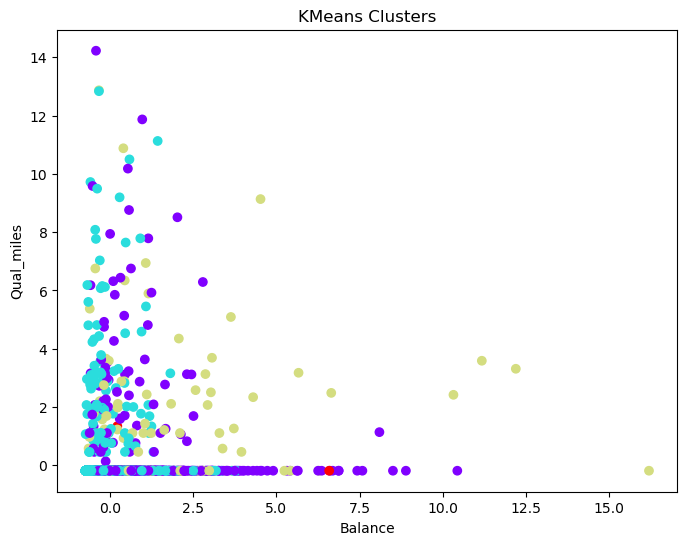

In [43]:
#Scatter Plot
plt.figure(figsize=(8,6))

plt.scatter(
    scaled_df.iloc[:,0],
    scaled_df.iloc[:,1],
    c=labels,
    cmap='rainbow'
)

plt.xlabel(scaled_df.columns[0])
plt.ylabel(scaled_df.columns[1])

plt.title("KMeans Clusters")

plt.show()

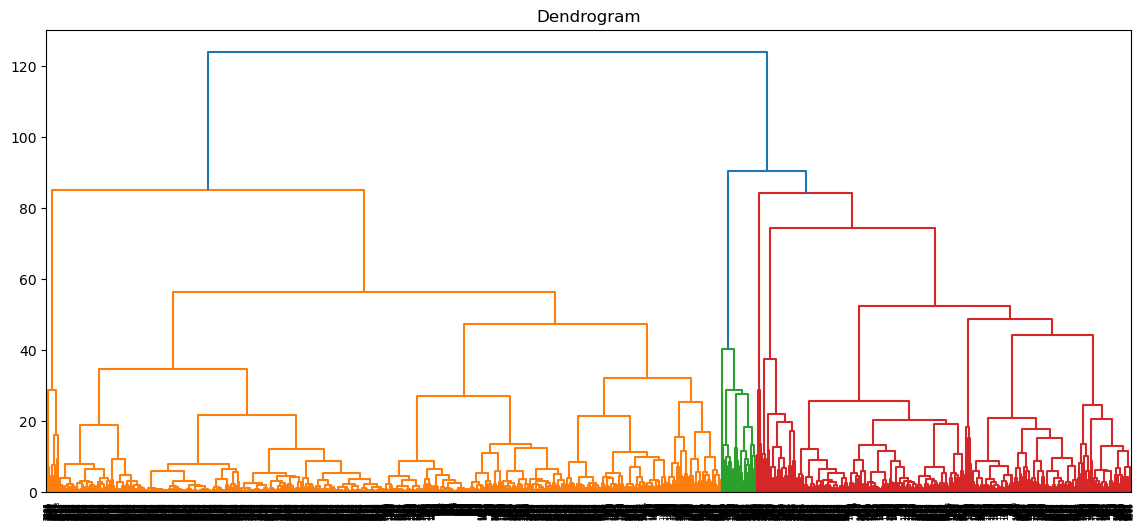

In [44]:
#HIERARCHICAL CLUSTERING
#Step 23: Dendrogram
linked = linkage(
    scaled_df,
    method='ward'
)

plt.figure(figsize=(14,6))

dendrogram(linked)

plt.title("Dendrogram")

plt.show()

In [45]:
#Train Hierarchical

#Suppose dendrogram suggests 4 clusters.

hc = AgglomerativeClustering(
    n_clusters=4,
    linkage='ward'
)

hc_labels = hc.fit_predict(scaled_df)

In [46]:
#Save Labels
df["Hierarchical"] = hc_labels

In [47]:
#Count Clusters
df["Hierarchical"].value_counts()

Hierarchical
1    2445
0    1380
2     130
3      43
Name: count, dtype: int64

In [48]:
#Silhouette Score
score = silhouette_score(
    scaled_df,
    hc_labels
)

print(score)

0.308036175465823


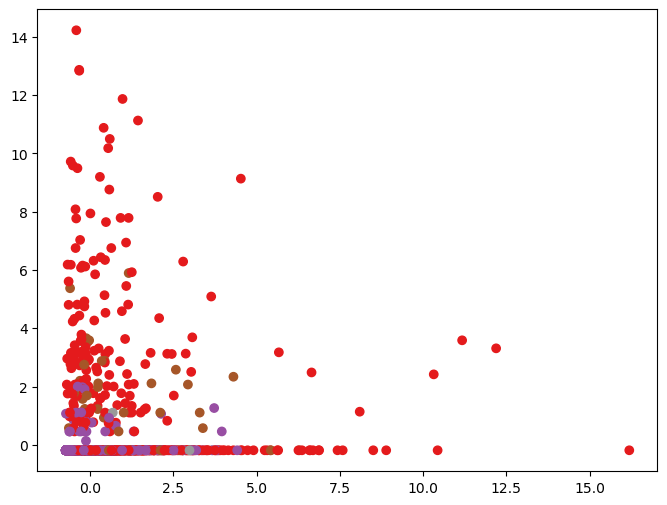

In [49]:
#Plot
plt.figure(figsize=(8,6))

plt.scatter(
    scaled_df.iloc[:,0],
    scaled_df.iloc[:,1],
    c=hc_labels,
    cmap='Set1'
)

plt.show()

In [50]:
#DBSCAN
#Step 29: Train DBSCAN
db = DBSCAN(
    eps=1.2,
    min_samples=5
)

db_labels = db.fit_predict(scaled_df)

In [51]:
#Save Labels
df["DBSCAN"] = db_labels

In [52]:
#Count Clusters
df["DBSCAN"].value_counts()

DBSCAN
 0    2378
 1    1150
-1     443
 2      14
 3       8
 4       5
Name: count, dtype: int64

In [53]:
#Silhouette Score
valid = db_labels != -1

if len(set(db_labels[valid])) > 1:
    score = silhouette_score(
        scaled_df[valid],
        db_labels[valid]
    )
    print(score)
else:
    print("Silhouette score cannot be calculated.")

0.27091398253949517


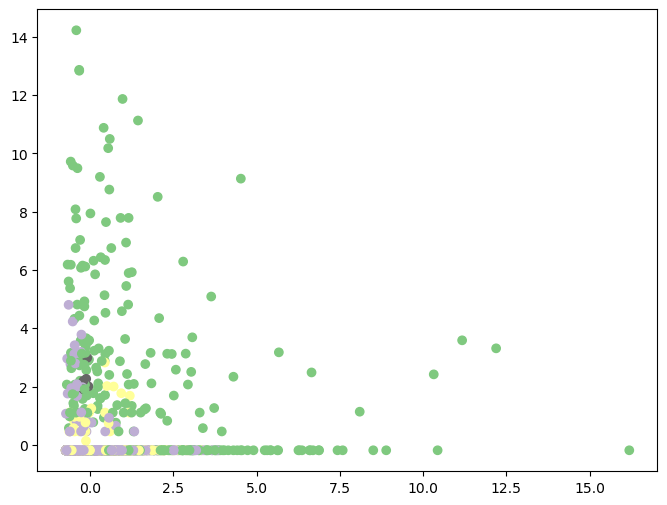

In [54]:
#Plot
plt.figure(figsize=(8,6))

plt.scatter(
    scaled_df.iloc[:,0],
    scaled_df.iloc[:,1],
    c=db_labels,
    cmap='Accent'
)

plt.show()

In [55]:
#Cluster Interpretation
#KMeans
df.groupby("KMeans_Cluster").mean(numeric_only=True)

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?,Hierarchical,DBSCAN
KMeans_Cluster,,,,,,,,,,,,,
0,116243.826698,153.790008,3.694770,1.002342,1.001561,38953.733802,18.722873,330.550351,0.984387,4886.189696,0.644028,0.087432,0.380172
1,43654.277032,97.782952,1.215864,1.019337,1.000395,4651.062747,6.896606,200.964878,0.623915,3690.293607,0.201657,0.970797,0.180347
2,194830.404762,775.863095,2.196429,1.035714,1.000000,32546.404762,26.875000,5354.065476,15.636905,4695.839286,0.815476,1.559524,-0.892857
3,138061.400000,78.800000,3.466667,1.000000,4.066667,93927.866667,28.066667,506.666667,1.600000,4613.866667,0.533333,0.000000,-1.000000


In [56]:
#Hierarchical
df.groupby("Hierarchical").mean(numeric_only=True)

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?,KMeans_Cluster,DBSCAN
Hierarchical,,,,,,,,,,,,,
0,116314.450725,363.839130,3.498551,1.000000,1.035507,37150.356522,18.066667,377.000000,1.150000,4696.888406,0.663043,0.186957,0.340580
1,46347.876483,9.032311,1.244172,1.000000,1.000000,4870.103476,6.910429,214.900613,0.674029,3770.226176,0.184458,0.970961,0.161963
2,134880.892308,393.323077,2.430769,1.000000,1.000000,36582.169231,29.338462,5915.523077,16.638462,4599.607692,0.753846,1.838462,-0.907692
3,68876.581395,23.255814,1.139535,2.348837,1.000000,14689.837209,17.534884,582.627907,2.209302,3968.930233,0.395349,1.023256,0.720930


In [57]:
#DBSCAN
df.groupby("DBSCAN").mean(numeric_only=True)

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?,KMeans_Cluster,Hierarchical
DBSCAN,,,,,,,,,,,,,
-1,195593.634312,1113.530474,2.762980,1.063205,1.110609,42315.851016,23.503386,2488.069977,7.255079,4792.004515,0.735892,0.966140,0.749436
0,55121.149706,21.793944,1.672414,1.000000,1.000000,9349.133726,8.593776,158.964256,0.472666,3800.419680,0.000000,0.831371,0.843987
1,65679.625217,18.853913,2.604348,1.000000,1.000000,23626.286957,13.202609,310.722609,0.996522,4533.683478,1.000000,0.424348,0.373043
2,34032.142857,0.000000,1.000000,2.000000,1.000000,8312.500000,12.285714,57.142857,0.357143,3315.928571,0.000000,1.000000,3.000000
3,36524.250000,0.000000,1.000000,3.000000,1.000000,15518.500000,14.500000,50.000000,0.250000,3179.625000,0.000000,1.000000,3.000000
4,60884.400000,1902.400000,3.400000,1.000000,1.000000,34665.000000,15.400000,200.000000,0.400000,4534.000000,1.000000,0.000000,0.000000


In [58]:
#Save Final Dataset

#Save the dataset with the assigned cluster labels.

df.to_excel("EastWestAirlines_Clustered.xlsx", index=False)

Cluster 1:
*Fliers who travel very often, buy flights regularly, and have accumulated a huge number of total miles.

Cluster 2:
*Passengers who do not fly constantly.

Cluster 3:
*Occasional fliers who have low mile balances and minimal flight activity over the last 12 months.

Data Scaling Was Essential: Because values like Balance go up into hundreds of thousands while cc1_miles ranges from 1 to 5, scaling the data (StandardScaler) prevented large numbers from completely overwhelming the clustering calculations.  
DBSCAN (Density-Based Clustering): DBSCAN is great at flagging outliers—like a few rare "point hoarders" with millions of unused miles who don't fit into normal customer brackets.  